In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
import copy
import joblib 
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [ ]:
import sys

sys.path.append("../")

from preprocess import preprocess

In [10]:
df = pd.read_csv("delhi_aqi_weather_daily.csv")

df.head()

,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI,AQI_Bucket,Temperature,Humidity,WindSpeed,WindDirection,Rain,month,day_of_week,day_of_year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,...,204.5,Severe,16.145833,68.083333,1.660000,95.708333,0.0,1,3,1
1,Delhi,2015-01-02,344.2,173.2,179.8,128.4,156.1,15.6,6.28,7.5,...,238.5,Satisfactory,15.037500,84.166667,1.600417,88.916667,3.4,1,4,2
2,Delhi,2015-01-03,473.9,20.1,12.7,102.7,244.7,42.5,0.04,29.8,...,77.6,Satisfactory,15.441667,84.000000,1.421667,276.791667,0.5,1,5,3
3,Delhi,2015-01-04,32.4,414.8,198.1,25.6,218.2,13.2,2.47,50.4,...,85.4,Satisfactory,14.162500,79.250000,2.807500,313.291667,0.0,1,6,4
4,Delhi,2015-01-05,312.8,155.8,143.1,106.8,6.1,4.9,4.04,2.0,...,396.8,Poor,13.995833,74.208333,5.365417,299.041667,0.0,1,0,5


In [5]:
df_copy = copy.deepcopy(df)

## Cleaning Data

In [6]:
df_copy["Date"] = pd.to_datetime(df_copy["Date"])
df_copy = df_copy.sort_values("Date").reset_index(drop=True)

In [12]:
df_copy.set_index("Date", inplace=True)

#### Clean Sensor Errors (Physically impossible values)

In [13]:
# If PM2.5 > PM10, the sensor malfunctioned
df_copy.loc[df_copy["PM25"] > df_copy["PM10"], ["PM25", "PM10"]] = np.nan

####  Remove extreme impossible spikes (e.g., PM2.5 of 0.4 or 800+)

In [14]:
df_copy.loc[df_copy["PM25"] <= 5, "PM25"] = np.nan
df_copy.loc[df_copy["PM10"] <= 5, "PM10"] = np.nan
df_copy.loc[df_copy["PM25"] > 900, "PM25"] = np.nan
df_copy.loc[df_copy["PM10"] > 1200, "PM10"] = np.nan

#### Interpolate the missing values created by cleaning

In [15]:
df_copy["PM25"] = df_copy["PM25"].interpolate(method='time')
df_copy["PM10"] = df_copy["PM10"].interpolate(method='time')

#### Fill any remaining numeric NaNs forward

In [16]:
numeric_cols = df_copy.select_dtypes(include=[np.number]).columns
df_copy[numeric_cols] = df_copy[numeric_cols].ffill().bfill()

In [18]:
df_copy.reset_index(inplace=True)

## Preprocess using `preprocess.py`

In [19]:
df_copy = preprocess(df_copy)

#### Verify feature column list

In [20]:
print(df_copy.columns.to_list())

['Date', 'City', 'PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection', 'Rain', 'month', 'day_of_week', 'day_of_year', 'year', 'day_sin', 'day_cos', 'Season_Monsoon', 'Season_Summer', 'Season_Winter', 'PM25_lag1', 'PM25_lag3', 'PM25_lag7', 'PM25_lag14', 'PM25_lag30', 'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM10_lag14', 'PM10_lag30', 'PM25_rolling_3', 'PM25_rolling_7', 'PM25_median_7', 'PM25_std_7', 'PM25_max_7', 'PM10_rolling_3', 'PM10_rolling_7', 'PM10_median_7', 'PM10_max_7']


In [21]:
df_copy["Target_PM25"] = df_copy["PM25"].shift(-1)
df_copy["Target_PM10"] = df_copy["PM10"].shift(-1)

df_copy = df_copy.dropna().reset_index(drop=True)

print(df_copy.shape)

df_copy.head()

(3602, 51)


,Date,City,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,PM25_rolling_7,PM25_median_7,PM25_std_7,PM25_max_7,PM10_rolling_3,PM10_rolling_7,PM10_median_7,PM10_max_7,Target_PM25,Target_PM10
0,2015-01-31,Delhi,136.757143,267.200,116.2,88.1,125.4,26.6,6.87,87.6,...,187.869388,129.528571,125.568082,397.300000,362.200,445.714286,457.0,576.0,143.985714,172.200
1,2015-02-01,Delhi,143.985714,172.200,85.1,0.9,146.2,47.1,2.99,91.0,...,151.681633,129.528571,85.148673,336.200000,267.200,405.028571,443.0,576.0,151.214286,211.225
2,2015-02-02,Delhi,151.214286,211.225,108.7,139.7,54.2,32.4,2.99,14.9,...,125.255102,129.528571,27.587554,151.214286,216.875,352.917857,362.2,557.4,158.442857,250.250
3,2015-02-03,Delhi,158.442857,250.250,160.1,110.9,97.6,34.1,4.79,49.8,...,129.904082,136.757143,30.320947,158.442857,211.225,325.382143,267.2,557.4,165.671429,289.275
4,2015-02-04,Delhi,165.671429,289.275,156.9,44.4,239.4,23.1,5.08,39.5,...,143.985714,143.985714,15.615499,165.671429,250.250,287.078571,267.2,457.2,172.900000,328.300


## Prediction Pipeline for PM2.5 model

In [ ]:
print(df_copy["Target_PM25"].describe())

In [22]:
df_copy[["Date","PM25","Target_PM25"]].head(10)

,Date,PM25,Target_PM25
0,2015-01-31,136.757143,143.985714
1,2015-02-01,143.985714,151.214286
2,2015-02-02,151.214286,158.442857
3,2015-02-03,158.442857,165.671429
4,2015-02-04,165.671429,172.900000
5,2015-02-05,172.900000,23.800000
6,2015-02-06,23.800000,207.100000
7,2015-02-07,207.100000,21.000000
8,2015-02-08,21.000000,476.600000
9,2015-02-09,476.600000,282.250000


In [13]:
df_copy[["Date","PM25"]].head(5)

,Date,PM25
0,2015-01-31,405.9
1,2015-02-01,4.2
2,2015-02-02,334.2
3,2015-02-03,292.7
4,2015-02-04,413.1


In [12]:
df_copy[["Date","PM25"]].tail(5)

,Date,PM25
3597,2024-12-06,277.0
3598,2024-12-07,257.3
3599,2024-12-08,374.7
3600,2024-12-09,332.0
3601,2024-12-10,121.7


In [14]:
df_copy.shape

(3602, 51)

In [24]:
df_copy.select_dtypes(include=['number']).corr()["Target_PM25"].sort_values()

PM10_lag7        -0.022756
Temperature      -0.018844
day_sin          -0.016342
PM10_lag30       -0.015835
PM10_lag14       -0.015628
Rain             -0.013540
Humidity         -0.008417
NO               -0.007646
year             -0.006386
AQI              -0.004506
Benzene          -0.004057
PM25_lag7        -0.000627
Toluene           0.000037
day_of_week       0.001104
NOx               0.001995
PM25_lag14        0.003997
SO2               0.006129
O3                0.007587
CO                0.008261
Xylene            0.009788
NH3               0.015233
NO2               0.016892
WindSpeed         0.017594
PM25_lag30        0.018324
PM10_lag3         0.025775
WindDirection     0.033934
day_cos           0.035571
month             0.037410
day_of_year       0.041288
PM10_max_7        0.042626
PM25_lag3         0.047933
PM25_std_7        0.048636
PM10_lag1         0.096335
PM10_median_7     0.097151
PM10_rolling_7    0.110991
PM10_rolling_3    0.164657
PM25_max_7        0.167265
P

In [16]:
print(df_copy.shape)

print(df_copy.columns.tolist())

(3602, 51)
['City', 'Date', 'PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection', 'Rain', 'month', 'day_of_week', 'day_of_year', 'year', 'day_sin', 'day_cos', 'Season_Monsoon', 'Season_Summer', 'Season_Winter', 'PM25_lag1', 'PM25_lag3', 'PM25_lag7', 'PM25_lag14', 'PM25_lag30', 'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM10_lag14', 'PM10_lag30', 'PM25_rolling_3', 'PM25_rolling_7', 'PM25_median_7', 'PM25_std_7', 'PM25_max_7', 'PM10_rolling_3', 'PM10_rolling_7', 'PM10_median_7', 'PM10_max_7', 'Target_PM25', 'Target_PM10']


#### `feature set`

In [25]:
feature_cols = [
    # Current pollutant features
    "PM25",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene",

    # Weather features
    "Temperature",
    "Humidity",
    "WindSpeed",
    "WindDirection",
    "Rain",

    # PM2.5 lag features
    "PM25_lag1",
    "PM25_lag3",
    "PM25_lag7",
    "PM25_lag14",
    "PM25_lag30",

    # PM10 lag features
    "PM10_lag1",
    "PM10_lag3",
    "PM10_lag7",
    "PM10_lag14",
    "PM10_lag30",

    # PM2.5 rolling features
    "PM25_rolling_3",
    "PM25_rolling_7",
    "PM25_median_7",
    "PM25_max_7",
    "PM25_std_7",

    # PM10 rolling features
    "PM10_rolling_3",
    "PM10_rolling_7",
    "PM10_median_7",
    "PM10_max_7",

    # Time features
    "year",
    "month",
    "day_of_week",
    "day_of_year",
    "day_sin",
    "day_cos",

    # Season features
    "Season_Monsoon",
    "Season_Summer",
    "Season_Winter"
]
   

X = df_copy[feature_cols]

y_pm25 = df_copy["Target_PM25"]
y_pm10 = df_copy["Target_PM10"]

print(X.shape)

(3602, 45)


#### Time-based train/test split

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [27]:
split = int(len(df_copy) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_pm25_train = y_pm25.iloc[:split]
y_pm25_test = y_pm25.iloc[split:]

y_pm10_train = y_pm10.iloc[:split]
y_pm10_test = y_pm10.iloc[split:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2881, 45)
Test : (721, 45)


### Train PM2.5 model

In [28]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [29]:
param_dist = {
    "n_estimators": [200, 300, 500, 700, 1000],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "max_depth": [3, 4, 5, 6, 8],

    "min_child_weight": [1, 3, 5, 7],

    "subsample": [0.6, 0.8, 1.0],

    "colsample_bytree": [0.6, 0.8, 1.0],

    "gamma": [0, 0.1, 0.3, 0.5],

    "reg_alpha": [0, 0.01, 0.1, 1],

    "reg_lambda": [1, 2, 5]
}

In [30]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,

    n_iter=30,          # good balance between speed and quality

    scoring="neg_root_mean_squared_error",

    cv=tscv,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

### Fit model

In [31]:
random_search.fit(X_train, y_pm25_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estima

In [32]:
print(random_search.best_params_)

{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [33]:
best_model = random_search.best_estimator_

### Prediction

In [34]:
y_pred_best = best_model.predict(X_test)

### Evaluation

In [35]:
mae = mean_absolute_error(y_pm25_test, y_pred_best)

rmse = np.sqrt(mean_squared_error(y_pm25_test, y_pred_best))

r2 = r2_score(y_pm25_test, y_pred_best)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 73.15
RMSE : 97.86
R²   : 0.2676


In [36]:
baseline_pred = X_test["PM25"]

print("Baseline MAE :", mean_absolute_error(y_pm25_test, baseline_pred))

print(
    "Baseline RMSE:",
    np.sqrt(mean_squared_error(y_pm25_test, baseline_pred))
)

print("Baseline R2  :", r2_score(y_pm25_test, baseline_pred))

Baseline MAE : 76.14812760055479
Baseline RMSE: 112.41538309563082
Baseline R2  : 0.03351495882198663


### Actual vs Predicted

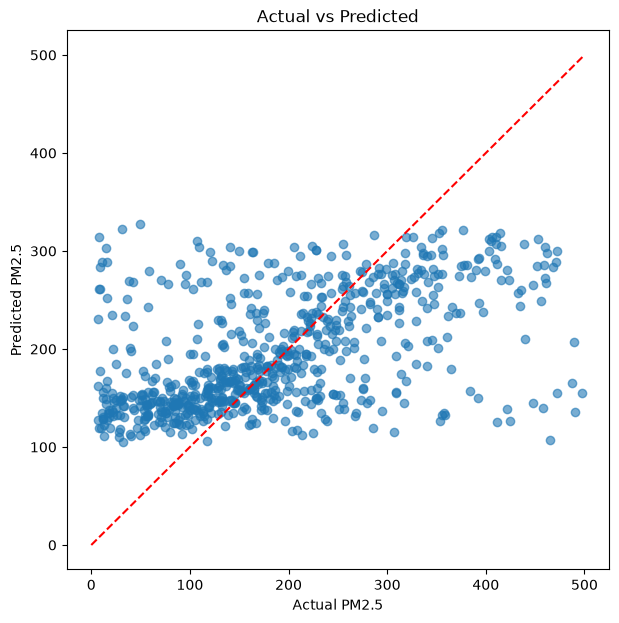

In [37]:
plt.figure(figsize=(7,7))
plt.scatter(y_pm25_test, y_pred_best, alpha=0.6)

plt.plot(
    [0, 500],
    [0, 500],
    "r--"
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")

plt.show()

In [38]:
comparison = pd.DataFrame({
    "Actual": y_pm25_test.values,
    "Predicted": y_pred_best
})

comparison.head(5)

,Actual,Predicted
0,236.9,128.577301
1,411.8,286.969757
2,170.1,275.977264
3,319.3,166.918808
4,468.5,283.406982


### Saving `PM2.5` model

In [58]:
joblib.dump(best_model, "pm25_xgboost_model.pkl")
print("model saved successfully")

model saved successfully


#### saving feature list

In [109]:
joblib.dump(feature_cols, "pm25_features.pkl")

['pm25_features.pkl']

#### saving metadata

In [59]:
metadata = {
    "target": "Target_PM25",
    "model": "XGBoost",
    "train_size": len(X_train),
    "test_size": len(X_test),
    "MAE"  : 73.15,
    "RMSE" : 97.86,
    "R²"   : 0.2676  
}

joblib.dump(metadata, "pm25_metadata.pkl")

['pm25_metadata.pkl']

## Prediction pipeline for PM10 model

In [39]:
print(df_copy["Target_PM10"].describe())

count    3602.000000
mean      398.286327
std       127.058102
min        10.200000
25%       307.687500
50%       414.637500
75%       502.650000
max       600.000000
Name: Target_PM10, dtype: float64


In [40]:
df_copy[["Date","PM10","Target_PM10"]].head(8)

,Date,PM10,Target_PM10
0,2015-01-31,267.200,172.200
1,2015-02-01,172.200,211.225
2,2015-02-02,211.225,250.250
3,2015-02-03,250.250,289.275
4,2015-02-04,289.275,328.300
5,2015-02-05,328.300,436.900
6,2015-02-06,436.900,288.600
7,2015-02-07,288.600,132.500


In [41]:
df_copy.select_dtypes(include=['number']).corr()["Target_PM10"].sort_values()

Rain             -0.037600
NO               -0.025634
year             -0.020484
Humidity         -0.019154
PM10_lag14       -0.015611
PM25_std_7       -0.009947
Benzene          -0.009806
day_of_week      -0.009430
NOx              -0.009429
PM10_lag7        -0.008749
NO2              -0.008168
PM25_lag14       -0.008001
NH3              -0.006313
day_sin          -0.000826
AQI               0.001085
day_cos           0.002176
O3                0.002358
WindDirection     0.003849
Toluene           0.005831
Xylene            0.010277
Temperature       0.015499
month             0.015747
PM25_lag7         0.016250
WindSpeed         0.018919
CO                0.019827
SO2               0.020037
day_of_year       0.021810
PM25_lag3         0.029419
PM10_lag30        0.037909
PM25_lag30        0.043647
PM10_lag3         0.060953
PM25_max_7        0.067836
PM10_max_7        0.096319
PM25_median_7     0.106158
PM25_lag1         0.116307
PM25_rolling_7    0.122150
PM25_rolling_3    0.175540
P

#### Fit model

In [42]:
random_search.fit(X_train, y_pm10_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estima

In [43]:
print(random_search.best_params_)

{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [44]:
best_model_PM10 = random_search.best_estimator_

#### Predict

In [45]:
y_pred_best_PM10 = best_model_PM10.predict(X_test)

#### Evaluation Mterics for PM10 Model

In [57]:
mae = mean_absolute_error(y_pm10_test, y_pred_best_PM10)

rmse = np.sqrt(mean_squared_error(y_pm10_test, y_pred_best_PM10))

r2 = r2_score(y_pm10_test, y_pred_best_PM10)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 85.29
RMSE : 111.20
R²   : 0.2444


#### Evaulation Mterics for PM10 Baseline Model

In [47]:
baseline_pred = X_test["PM10"]

print("Baseline MAE :", mean_absolute_error(y_pm10_test, baseline_pred))

print(
    "Baseline RMSE:",
    np.sqrt(mean_squared_error(y_pm10_test, baseline_pred))
)

print("Baseline R2  :", r2_score(y_pm10_test, baseline_pred))

Baseline MAE : 89.96393897364771
Baseline RMSE: 129.88399795842986
Baseline R2  : -0.03085476016190314


### Actual VS Predicted Data

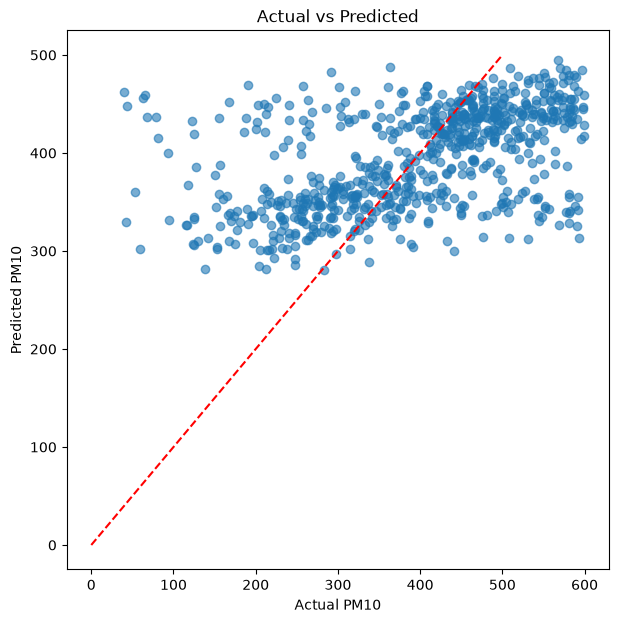

In [48]:
plt.figure(figsize=(7,7))
plt.scatter(y_pm10_test, y_pred_best_PM10, alpha=0.6)

plt.plot(
    [0, 500],
    [0, 500],
    "r--"
)

plt.xlabel("Actual PM10")
plt.ylabel("Predicted PM10")
plt.title("Actual vs Predicted")

plt.show()

In [49]:
comparison = pd.DataFrame({
    "Actual": y_pm10_test.values,
    "Predicted": y_pred_best_PM10
})

comparison.head(5)

,Actual,Predicted
0,588.00,345.473633
1,587.40,467.961609
2,584.30,429.676300
3,535.85,437.189484
4,487.40,433.563843


### Saving `PM10` Model

In [60]:
joblib.dump(best_model_PM10, "pm10_xgboost_model.pkl")

['pm10_xgboost_model.pkl']

#### saving metadata

In [61]:
metadata = {
    "target": "Target_PM10",
    "model": "XGBoost",
    "train_size": len(X_train),
    "test_size": len(X_test),
    "MAE"  : 85.29,
    "RMSE" : 111.20,
    "R²"   : 0.2444
}

joblib.dump(metadata, "pm10_metadata.pkl")

['pm10_metadata.pkl']

#### `NOTE` - Feature list is common for both models